## Проверка совпадения разметки в файле с отрисовкой

In [1]:
import cv2
import numpy as np
import json
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as MPLPolygon
from matplotlib.collections import PatchCollection
import random

In [6]:
def load_annotation(json_path):
    """
    Загружает JSON файл с разметкой
    """
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    return data

def draw_polygons_on_image(image, polygons, color=(0, 255, 0), thickness=2, fill_transparent=False, alpha=0.3):
    """
    Рисует полигоны на изображении
    
    Args:
        image: изображение (numpy array)
        polygons: список полигонов, каждый полигон - список точек [[x,y], [x,y], ...]
        color: цвет в BGR (по умолчанию зеленый)
        thickness: толщина линии
        fill_transparent: заливать ли полигон полупрозрачным цветом
        alpha: прозрачность заливки (0-1)
    """
    img_copy = image.copy()
    
    for polygon in polygons:
        pts = np.array(polygon, dtype=np.int32)
        
        cv2.polylines(img_copy, [pts], isClosed=True, color=color, thickness=thickness)
        
        if fill_transparent:
            mask = np.zeros(image.shape[:2], dtype=np.uint8)
            cv2.fillPoly(mask, [pts], 255)
            
            overlay = np.zeros_like(image)
            overlay[mask == 255] = color
            
            cv2.addWeighted(overlay, alpha, img_copy, 1 - alpha, 0, img_copy)
    
    return img_copy

def visualize_annotation(image_path, json_path, output_path=None, 
                        color=(0, 255, 0), thickness=2, 
                        fill=True, alpha=0.3, show_points=False):
    """
    Визуализирует разметку на изображении
    """
    image = cv2.imread(str(image_path))
    if image is None:
        print(f"Не удалось загрузить изображение {image_path}")
        return None
    
    try:
        annotation = load_annotation(json_path)
    except Exception as e:
        print(f"Ошибка загрузки JSON: {e}")
        return None
    
    polygons = annotation.get('polygons', [])
    print(f"Найдено полигонов: {len(polygons)}")
    
    result_image = draw_polygons_on_image(image, polygons, color, thickness, fill, alpha)
    
    if show_points:
        for polygon in polygons:
            for point in polygon:
                cv2.circle(result_image, (int(point[0]), int(point[1])), 5, (0, 0, 255), -1)
    
    if output_path:
        cv2.imwrite(str(output_path), result_image)
        print(f"Сохранено: {output_path}")
    
    return result_image, annotation

def visualize_matplotlib(image, polygons, title="Разметка", figsize=(12, 10)):
    """
    Визуализация с помощью matplotlib (лучше для отображения в ноутбуке)
    """
    img_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img_rgb)
    
    for polygon in polygons:
        poly_points = np.array(polygon)
        
        poly_patch = MPLPolygon(poly_points, closed=True, 
                               fill=False, edgecolor='lime', linewidth=2)
        ax.add_patch(poly_patch)
        
        ax.plot(poly_points[:, 0], poly_points[:, 1], 'ro', markersize=3)
    
    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    return fig, ax

In [7]:
# Путь к папке с изображениями
IMAGES_DIR = Path("C:/Recognition of unpaved roads/1_stage/images") 

# Путь к папке с JSON файлами разметки
ANNOTATIONS_DIR = Path("C:/Recognition of unpaved roads/1_stage/annotations")  

print(f"Изображения: {IMAGES_DIR}")
print(f"Аннотации: {ANNOTATIONS_DIR}")

# Проверяем, что папки существуют
if not IMAGES_DIR.exists():
    print(f"Папка с изображениями не найдена: {IMAGES_DIR}")
if not ANNOTATIONS_DIR.exists():
    print(f"Папка с аннотациями не найдена: {ANNOTATIONS_DIR}")

Изображения: C:\Recognition of unpaved roads\1_stage\images
Аннотации: C:\Recognition of unpaved roads\1_stage\annotations


In [8]:
def find_image_annotation_pairs(images_dir, annotations_dir):
    """
    Находит пары изображение-JSON по совпадению имен
    """
    pairs = []
    
    image_extensions = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tiff']
    images = []
    for ext in image_extensions:
        images.extend(images_dir.glob(ext))
    
    for img_path in images:
        json_path = annotations_dir / f"{img_path.stem}.json"
        
        if json_path.exists():
            pairs.append((img_path, json_path))
        else:
            print(f"Нет JSON для: {img_path.name}")
    
    print(f"Найдено пар: {len(pairs)}")
    return pairs

pairs = find_image_annotation_pairs(IMAGES_DIR, ANNOTATIONS_DIR)

if len(pairs) == 0:
    print("Не найдено ни одной пары!")

Нет JSON для: 2023_Panskoe_M2000-1-2.jpeg
Найдено пар: 336


Image: 2023_Alyoshnya_M2000-2-2.jpeg
JSON: 2023_Alyoshnya_M2000-2-2.json


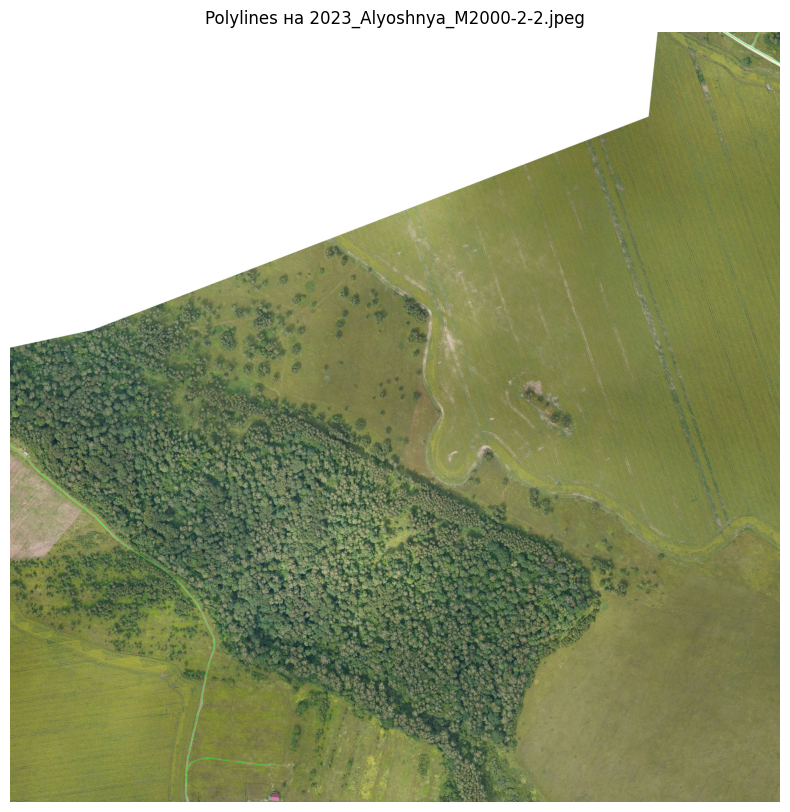


Information about annotation:
   image_id: 66
   size: {'width': '5000', 'height': '5000'}
   number of polylines: 4
   first polyline: 3 points
   example points: [[4642.91, 0.0], [4796.48, 91.6], [5000.0, 203.54]]...


In [9]:
if len(pairs) > 0:
    first_image_path, first_json_path = pairs[0]
    
    print(f"Image: {first_image_path.name}")
    print(f"JSON: {first_json_path.name}")
    print("="*50)
    
    # Загружаем изображение и JSON
    image = cv2.imread(str(first_image_path))
    with open(first_json_path, 'r') as f:
        annotation = json.load(f)
    
    # Для polylines
    polylines = annotation.get('polylines', [])
    
    # Создаем копию изображения для отрисовки
    result_image = image.copy()
    
    # Рисуем линии
    for polyline in polylines:
        pts = np.array(polyline, dtype=np.int32)
        cv2.polylines(result_image, [pts], isClosed=False, color=(0, 255, 0), thickness=2)
    
    # Визуализация
    plt.figure(figsize=(12, 10))
    plt.imshow(cv2.cvtColor(result_image, cv2.COLOR_BGR2RGB))
    plt.title(f"Polylines на {first_image_path.name}")
    plt.axis('off')
    plt.show()
    
    print("\nInformation about annotation:")
    print(f"   image_id: {annotation.get('image_id', 'N/A')}")
    print(f"   size: {annotation.get('size', {})}")
    print(f"   number of polylines: {len(polylines)}")
    
    if len(polylines) > 0:
        print(f"   first polyline: {len(polylines[0])} points")
        print(f"   example points: {polylines[0][:3]}...")
else:
    print("No pairs found for visualization")

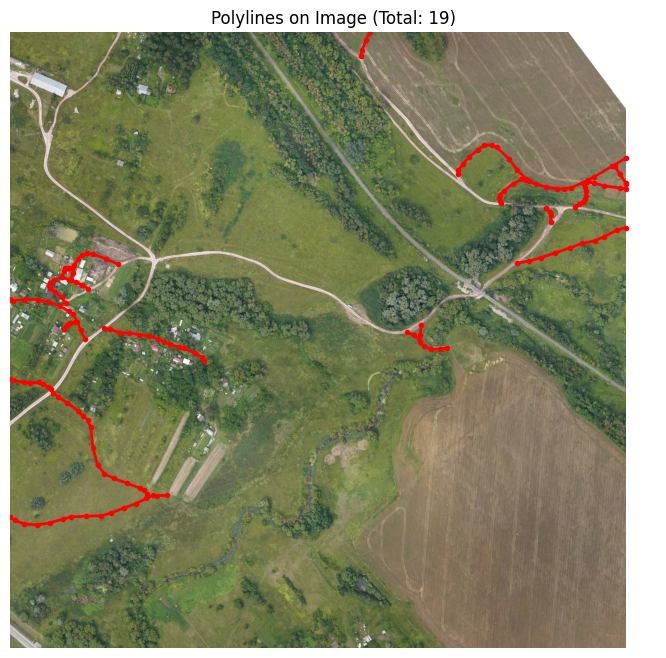

In [3]:
import cv2
import json
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

IMAGE_PATH = Path("C:/Recognition of unpaved roads/1_stage/images/2023_Alyoshnya_M2000-5-1.jpeg")
JSON_PATH = Path("C:/Recognition of unpaved roads/1_stage/annotations/2023_Alyoshnya_M2000-5-1.json")

image = cv2.imread(str(IMAGE_PATH))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

with open(JSON_PATH, 'r') as f:
    annotation = json.load(f)

polylines = annotation.get('polylines', [])

plt.figure(figsize=(12, 8))
plt.imshow(image_rgb)

for polyline in polylines:
    pts = np.array(polyline)
    plt.plot(pts[:, 0], pts[:, 1], color='red', linewidth=2, marker='o', markersize=3)

plt.title(f'Polylines on Image (Total: {len(polylines)})')
plt.axis('off')
plt.show()